In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = Ball3StickSharedDiffusivity
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [2]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition


@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    #model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    model_mask = jnp.ones(len(sim_type.model_types), dtype=jnp.bool)
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    @jax.grad
    def posterior_score(theta, x):
        ball_stick = sim_type.from_theta(theta, model_mask=model_mask)
        return ball_stick.log_likelihood(acq, x) + jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

    x_o = ball_stick.signal(acq, rng=rng5)
    score = posterior_score(theta, x_o)
    return p_mask, model_mask, theta, x_o, acq, score


In [3]:
p_mask,masks, theta, x_o, acq, score= jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

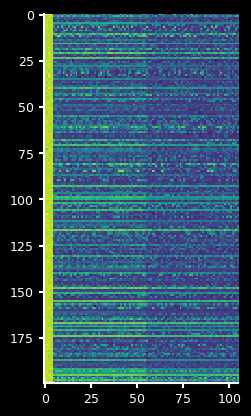

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_o)

In [5]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized, DMRIInferenceModelConfigMaskPriorAmortizedPP
from dmri.nn.tokenizer import DMRITokenizerPP

cfg = DMRIInferenceModelConfigMaskPriorAmortizedPP(sim_type, use_attention_mask=False)
cfg.theta_inference_cfg.widening_factor = 4
cfg.theta_inference_cfg.num_heads = 8
cfg.theta_inference_cfg.num_layers=12
cfg.theta_inference_cfg.attn_size = 8
cfg.model_dim=128
model = DMRIInferenceModel(cfg, nnx.Rngs(0))

In [6]:
# import pickle
# pickle.dump(params, open("params.pkl", "wb"))

In [7]:
import pickle
params = pickle.load(open("ema_params.pkl", "rb"))

In [8]:
nnx.update(model, params)

In [9]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

In [10]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


In [11]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [12]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

In [13]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool)).signal(acq, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool))
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals, acq.bvecs), x_o)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

from blackjax import tempered_smc
from blackjax import hmc
from functools import partial
from blackjax.smc.resampling import systematic

@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.015, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=1.)

    def step(state, rng):
        new_state, info = smc.step(rng, state, 1.)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        return new_state, info

    rng_keys = jax.random.split(jax.random.key(0), 20)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles


In [14]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

def log_likelihood_fn(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def posterior_pred(theta, rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def smc(rng,thetas,model_mask, acq, x_o):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.015, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic
    _log_likelihood_fn = partial(log_likelihood_fn, mask=model_mask, acq=acq, x=x_o)
    smc = tempered_smc(log_prior_fn, _log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=1.)

    def step(state, rng):
        new_state, info = smc.step(rng, state, 1.)
        return new_state, info

    rng_keys = jax.random.split(rng, 10)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles, final_state.weights


def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    K = 50
    propose_fn = partial(model.sample_theta, num_steps=32, max_noise=80)
    key_k = jax.random.split(key, K)
    theta = jax.vmap(propose_fn, in_axes=(0,None,None,None, None))(key_k, acq.bvals, acq.bvecs, x,model_mask)
    theta_corr, weights = smc(subkey, theta, model_mask, acq, x)
    return theta_corr, weights

sample_theta_per_x = jax.jit(jax.vmap(sample_mcmc_correct))

In [15]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [16]:
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, 1.4)

In [17]:
def posterior_pred(theta):
    return sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool)).signal(acq, rng=None)

In [254]:
import pickle

thetas = pickle.load(open("thetas_full.pkl", "rb"))

In [255]:
def mse(thetas, data):
    xs_pred = jax.vmap(posterior_pred)(thetas)
    return jnp.mean((xs_pred - data[...,None,:])**2)


In [256]:
jax.clear_caches()

In [257]:
pred_error1 = np.array(jax.vmap(mse)(thetas[:100_000], full_data_flat_in_brain[:100_000]))

In [258]:
pred_error2 = np.array(jax.vmap(mse)(thetas[100_000:200_000], full_data_flat_in_brain[100_000:200_000]))

In [259]:
pred_error3 = np.array(jax.vmap(mse)(thetas[200_000:300_000], full_data_flat_in_brain[200_000:300_000]))

In [260]:
pred_error = np.concat([pred_error1, pred_error2, pred_error3], axis=0)

In [261]:
pred_error.mean()

np.float32(0.0053532827)

In [262]:
def to_fractions(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_fractions

def to_diffusivities(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[0].lam

def direction_s1(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[1].mu

def direction_s2(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[2].mu

def direction_s3(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).model_compartments[3].mu

def snr(theta):
    return sim_type.from_theta(theta, model_mask=model_mask).noise_compartments[0].snr


fractions = jax.vmap(jax.vmap(to_fractions))(thetas)
diffusivities = jax.vmap(jax.vmap(to_diffusivities))(thetas)
directions_s1 = jax.vmap(jax.vmap(direction_s1))(thetas)
directions_s2 = jax.vmap(jax.vmap(direction_s2))(thetas)
directions_s3 = jax.vmap(jax.vmap(direction_s3))(thetas)
snr = jax.vmap(jax.vmap(snr))(thetas)


In [263]:

def sph2cart(angles):
    theta, phi = angles[..., 0], angles[..., 1]
    x = jnp.sin(theta) * jnp.cos(phi)
    y = jnp.sin(theta) * jnp.sin(phi)
    z = jnp.cos(theta)
    return jnp.stack([x, y, z], axis=-1)

directions_s1_in_brain = jax.vmap(jax.vmap(sph2cart))(directions_s1)
directions_s2_in_brain = jax.vmap(jax.vmap(sph2cart))(directions_s2)
directions_s3_in_brain = jax.vmap(jax.vmap(sph2cart))(directions_s3)


In [411]:
directions_s1.shape

(227840, 50, 2)

In [412]:
dyads1_in_brain_unordered, dyads1_disp_unordered = jax.vmap(make_dyads)(directions_s1[...,0], directions_s1[...,1])
dyads2_in_brain_unordered, dyads2_disp_unordered = jax.vmap(make_dyads)(directions_s2[...,0], directions_s2[...,1])
dyads3_in_brain_unordered, dyads3_disp_unordered = jax.vmap(make_dyads)(directions_s3[...,0], directions_s3[...,1])


(3, 3)
(3, 3)
(3, 3)


In [348]:
from sklearn.decomposition import PCA
def reorder_angles_for_consistency(angles1, angles2, angles3, n_references=2):
    """
    Reorder fiber directions across the batch so that similar directions are consistently aligned
    for meaningful averaging using PCA to determine multiple global reference directions.

    Args:
        angles1: [N, 2] array of [theta, phi] directions
        angles2: [N, 2] array of [theta, phi] directions
        angles3: [N, 2] array of [theta, phi] directions
        n_references: Number of PCA components to use as global references

    Returns:
        reordered_angles1: [N, 2] aligned to the dominant global direction(s)
        reordered_angles2: [N, 2] second-best aligned direction(s)
        reordered_angles3: [N, 2] least aligned direction(s)
    """


    v1 = sph2cart(angles1)
    v2 = sph2cart(angles2)
    v3 = sph2cart(angles3)

    # Convert nan to random vector


    # === Step 1: Use PCA of all vectors to get global references ===
    all_vectors = np.vstack([v1, v2, v3])
    # Covert nan to 0
    all_vectors[np.isnan(all_vectors)] = np.random.randn(*all_vectors[np.isnan(all_vectors)].shape)*0.01
    pca = PCA(n_components=n_references)
    pca.fit(all_vectors)
    global_refs = pca.components_

    # === Step 2: Compute maximum alignment of each vector to global references ===
    def max_dot(vectors):
        dots = vectors @ global_refs.T
        return np.max(dots, axis=1)

    dot1 = max_dot(v1)
    dot2 = max_dot(v2)
    dot3 = max_dot(v3)

    # Stack dots and angles for sorting
    dots = np.stack([dot1, dot2, dot3], axis=1)
    angles_stacked = np.stack([angles1, angles2, angles3], axis=1)

    # === Step 3: Sort angles based on alignment ===
    sorted_indices = np.argsort(-dots, axis=1)

    reordered_angles1 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 0], :]
    reordered_angles2 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 1], :]
    reordered_angles3 = angles_stacked[np.arange(len(angles1)), sorted_indices[:, 2], :]

    return reordered_angles1, reordered_angles2, reordered_angles3

# Example loop for reordering angles for all samples
mu_s1_reordered, mu_s2_reordered, mu_s3_reordered = [], [], []
for i in range(directions_s1.shape[1]):
    angles1, angles2, angles3 = reorder_angles_for_consistency(
        directions_s1[:, i], directions_s2[:, i], directions_s3[:, i])
    mu_s1_reordered.append(angles1)
    mu_s2_reordered.append(angles2)
    mu_s3_reordered.append(angles3)

In [391]:
def reorder_angles_3fib(mu1, mu2, mu3):
    """Reorder angles to maintain consistency across samples by comparing to reference vectors.

    Args:
        mu1, mu2, mu3: Arrays of shape (n_samples, 2) containing spherical angles (theta, phi)

    Returns:
        new_mu1, new_mu2, new_mu3: Reordered angles arrays of same shape as inputs
    """
    # Initialize output arrays
    new_mu1 = jnp.zeros_like(mu1)
    new_mu2 = jnp.zeros_like(mu2)
    new_mu3 = jnp.zeros_like(mu3)

    # Use first sample as reference vectors
    v1_ref = sph2cart(mu1[0])
    v2_ref = sph2cart(mu2[0])
    v3_ref = sph2cart(mu3[0])

    # Copy first sample directly
    new_mu1 = new_mu1.at[0].set(mu1[0])
    new_mu2 = new_mu2.at[0].set(mu2[0])
    new_mu3 = new_mu3.at[0].set(mu3[0])

    # Process remaining samples
    for j in range(1, len(mu1)):
        # Convert current sample to cartesian
        v1 = sph2cart(mu1[j])
        v2 = sph2cart(mu2[j])
        v3 = sph2cart(mu3[j])

        # Calculate dot products with v1_ref
        dots = jnp.array([
            jnp.dot(v1_ref, v1)/(jnp.linalg.norm(v1_ref)*jnp.linalg.norm(v1)),
            jnp.dot(v1_ref, v2)/(jnp.linalg.norm(v1_ref)*jnp.linalg.norm(v2)),
            jnp.dot(v1_ref, v3)/(jnp.linalg.norm(v1_ref)*jnp.linalg.norm(v3))
        ])

        # Find best match for v1_ref
        best_match = np.argmax(dots)

        # Reorder based on best match with v1_ref using where
        angles1 = jnp.where(best_match == 0, mu1[j],
                  jnp.where(best_match == 1, mu2[j], mu3[j]))

        remaining = jnp.where(best_match == 0, jnp.array([mu2[j], mu3[j]]),
                   jnp.where(best_match == 1, jnp.array([mu1[j], mu3[j]]),
                                            jnp.array([mu1[j], mu2[j]])))

        v_remaining = jnp.where(best_match == 0, jnp.array([v2, v3]),
                     jnp.where(best_match == 1, jnp.array([v1, v3]),
                                              jnp.array([v1, v2])))

        # Find best match for v2_ref among remaining vectors
        dots_v2 = jnp.array([
            jnp.dot(v2_ref, v_remaining[0])/(jnp.linalg.norm(v2_ref)*jnp.linalg.norm(v_remaining[0])),
            jnp.dot(v2_ref, v_remaining[1])/(jnp.linalg.norm(v2_ref)*jnp.linalg.norm(v_remaining[1]))
        ])

        # Order remaining two vectors based on similarity to v2_ref using where
        angles2 = jnp.where(dots_v2[0] > dots_v2[1], remaining[0], remaining[1])
        angles3 = jnp.where(dots_v2[0] > dots_v2[1], remaining[1], remaining[0])

        # Store reordered angles
        new_mu1 = new_mu1.at[j].set(angles1)
        new_mu2 = new_mu2.at[j].set(angles2)
        new_mu3 = new_mu3.at[j].set(angles3)

    return new_mu1, new_mu2, new_mu3

In [389]:
mu_s1_reordered = np.stack(mu_s1_reordered, axis=1)
mu_s2_reordered = np.stack(mu_s2_reordered, axis=1)
mu_s3_reordered = np.stack(mu_s3_reordered, axis=1)

In [399]:
mu_s1_reordered, mu_s2_reordered, mu_s3_reordered = jax.vmap(reorder_angles_3fib)(directions_s1, directions_s2, directions_s3)

(array([ 2.,  1.,  1.,  7.,  1.,  1., 11.,  6., 11.,  9.]),
 array([0.408, 0.522, 0.637, 0.751, 0.865, 0.979, 1.094, 1.208, 1.322,
        1.437, 1.551]),
 <BarContainer object of 10 artists>)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

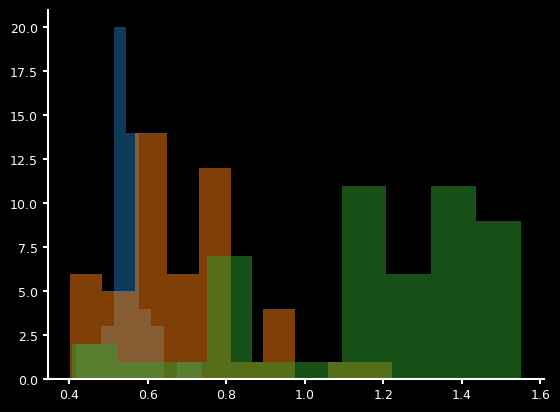

In [400]:
plt.hist(mu_s1_reordered[26_500,:,0], alpha=0.5)
plt.hist(mu_s2_reordered[26_500,:,0], alpha=0.5)
plt.hist(mu_s3_reordered[26_500,:,0], alpha=0.5)


(array([ 9., 10.,  4.,  6.,  2.,  2.,  3.,  1.,  6.,  7.]),
 array([0.452, 0.562, 0.672, 0.782, 0.892, 1.002, 1.111, 1.221, 1.331,
        1.441, 1.551]),
 <BarContainer object of 10 artists>)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

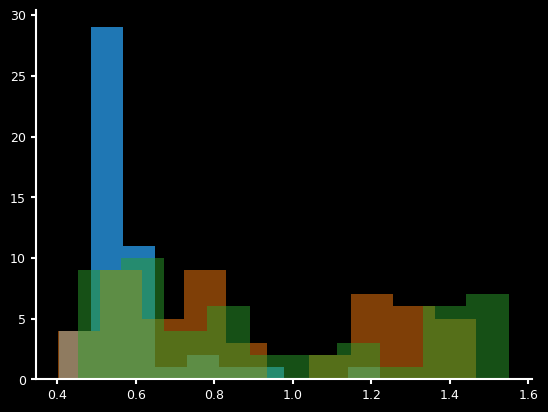

In [401]:
plt.hist(directions_s1[26_500,:,0])
plt.hist(directions_s2[26_500,:,0], alpha=0.5)
plt.hist(directions_s3[26_500,:,0], alpha=0.5)

In [402]:


directions_s1_reordered = jax.vmap(jax.vmap(sph2cart))(mu_s1_reordered)
directions_s2_reordered = jax.vmap(jax.vmap(sph2cart))(mu_s2_reordered)
directions_s3_reordered = jax.vmap(jax.vmap(sph2cart))(mu_s3_reordered)


In [403]:
from dmri.utils.dmriutils import make_dyads

s1_dyads_mean = jax.vmap(partial(make_dyads))(mu_s1_reordered[...,0], mu_s1_reordered[...,1])[0]
s1_dyads_disp = jax.vmap(partial(make_dyads))(mu_s1_reordered[...,0], mu_s1_reordered[...,1])[1]
s2_dyads_mean = jax.vmap(partial(make_dyads))(mu_s2_reordered[...,0], mu_s2_reordered[...,1])[0]
s2_dyads_disp = jax.vmap(partial(make_dyads))(mu_s2_reordered[...,0], mu_s2_reordered[...,1])[1]
s3_dyads_mean = jax.vmap(partial(make_dyads))(mu_s3_reordered[...,0], mu_s3_reordered[...,1])[0]
s3_dyads_disp = jax.vmap(partial(make_dyads))(mu_s3_reordered[...,0], mu_s3_reordered[...,1])[1]


(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)
(3, 3)


In [161]:
f0 = np.array(fractions)[...,0]
f1 = np.array(fractions)[...,1]
f2 = np.array(fractions)[...,2]
f3 = np.array(fractions)[...,3]


In [176]:
f0_mean = np.mean(f0, axis=-1)
f1_mean = np.mean(f1, axis=-1)
f2_mean = np.mean(f2, axis=-1)
f3_mean = np.mean(f3, axis=-1)


f0_std = np.std(f0, axis=-1)
f1_std = np.std(f1, axis=-1)
f2_std = np.std(f2, axis=-1)
f3_std = np.std(f3, axis=-1)

In [178]:
diff_mean = np.mean(diffusivities, axis=-1)
diff_std = np.std(diffusivities, axis=-1)

snr_mean = np.mean(snr, axis=-1)
snr_std = np.std(snr, axis=-1)

In [179]:
f0.shape

(227840, 50)

In [192]:
full_data_f0_mean = np.zeros(full_data_flat.shape[:-1])
full_data_f0_mean[brain_mask_flat.astype(np.bool)] = f0_mean
full_data_f0_mean = full_data_f0_mean.reshape(data_norm.shape[:-1])[...,None]

full_data_f1_mean = np.zeros(full_data_flat.shape[:-1])
full_data_f1_mean[brain_mask_flat.astype(np.bool)] = f1_mean
full_data_f1_mean = full_data_f1_mean.reshape(data_norm.shape[:-1])[...,None]

full_data_f2_mean = np.zeros(full_data_flat.shape[:-1])
full_data_f2_mean[brain_mask_flat.astype(np.bool)] = f2_mean
full_data_f2_mean = full_data_f2_mean.reshape(data_norm.shape[:-1])[...,None]

full_data_f3_mean = np.zeros(full_data_flat.shape[:-1])
full_data_f3_mean[brain_mask_flat.astype(np.bool)] = f3_mean
full_data_f3_mean = full_data_f3_mean.reshape(data_norm.shape[:-1])[...,None]

# For std
full_data_f0_std = np.zeros(full_data_flat.shape[:-1])
full_data_f0_std[brain_mask_flat.astype(np.bool)] = f0_std
full_data_f0_std = full_data_f0_std.reshape(data_norm.shape[:-1])[...,None]

full_data_f1_std = np.zeros(full_data_flat.shape[:-1])
full_data_f1_std[brain_mask_flat.astype(np.bool)] = f1_std
full_data_f1_std = full_data_f1_std.reshape(data_norm.shape[:-1])[...,None]

full_data_f2_std = np.zeros(full_data_flat.shape[:-1])
full_data_f2_std[brain_mask_flat.astype(np.bool)] = f2_std
full_data_f2_std = full_data_f2_std.reshape(data_norm.shape[:-1])[...,None]

full_data_f3_std = np.zeros(full_data_flat.shape[:-1])
full_data_f3_std[brain_mask_flat.astype(np.bool)] = f3_std
full_data_f3_std = full_data_f3_std.reshape(data_norm.shape[:-1])[...,None]


(array([37482., 62915., 63313., 31873., 17080.,  9155.,  4495.,  1319.,
          201.,     7.]),
 array([0.   , 0.029, 0.057, 0.086, 0.115, 0.144, 0.172, 0.201, 0.23 ,
        0.258, 0.287]),
 <BarContainer object of 10 artists>)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

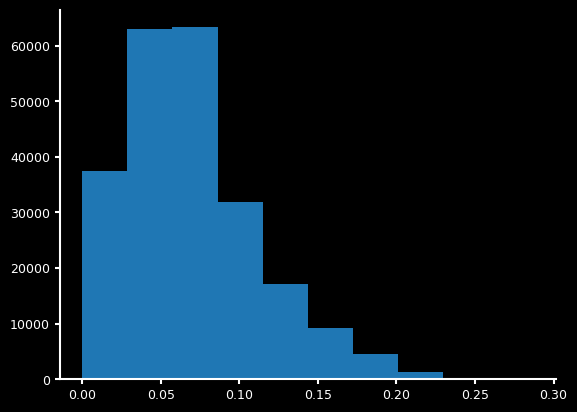

In [223]:
plt.hist(f3_mean.flatten())

In [234]:
full_data_pred_error = np.zeros(full_data_flat.shape[:-1])
full_data_pred_error[brain_mask_flat.astype(np.bool)] = pred_error
full_data_pred_error = full_data_pred_error.reshape(data_norm.shape[:-1])[...,None]

In [202]:
# Full data diffusivities
full_data_diff = np.zeros(full_data_flat.shape[:-1])
full_data_diff[brain_mask_flat.astype(np.bool)] = diff_mean
full_data_diff = full_data_diff.reshape(data_norm.shape[:-1])[...,None]

# Std
full_data_diff_std = np.zeros(full_data_flat.shape[:-1])
full_data_diff_std[brain_mask_flat.astype(np.bool)] = diff_std
full_data_diff_std = full_data_diff_std.reshape(data_norm.shape[:-1])[...,None]


In [404]:
# Dispersion
full_data_s1_dispersion = np.zeros(full_data_flat.shape[:-1])
full_data_s1_dispersion[brain_mask_flat.astype(np.bool)] = s1_dyads_disp
full_data_s1_dispersion = full_data_s1_dispersion.reshape(data_norm.shape[:-1])[...,None]

full_data_s2_dispersion = np.zeros(full_data_flat.shape[:-1])
full_data_s2_dispersion[brain_mask_flat.astype(np.bool)] = s2_dyads_disp
full_data_s2_dispersion = full_data_s2_dispersion.reshape(data_norm.shape[:-1])[...,None]

full_data_s3_dispersion = np.zeros(full_data_flat.shape[:-1])
full_data_s3_dispersion[brain_mask_flat.astype(np.bool)] = s3_dyads_disp
full_data_s3_dispersion = full_data_s3_dispersion.reshape(data_norm.shape[:-1])[...,None]

# Dyads
full_data_s1_dyads = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_s1_dyads[brain_mask_flat.astype(np.bool)] = s1_dyads_mean
full_data_s1_dyads = full_data_s1_dyads.reshape(data_norm.shape[:-1] + (3,))

full_data_s2_dyads = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_s2_dyads[brain_mask_flat.astype(np.bool)] = s2_dyads_mean
full_data_s2_dyads = full_data_s2_dyads.reshape(data_norm.shape[:-1] + (3,))

full_data_s3_dyads = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_s3_dyads[brain_mask_flat.astype(np.bool)] = s3_dyads_mean
full_data_s3_dyads = full_data_s3_dyads.reshape(data_norm.shape[:-1] + (3,))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

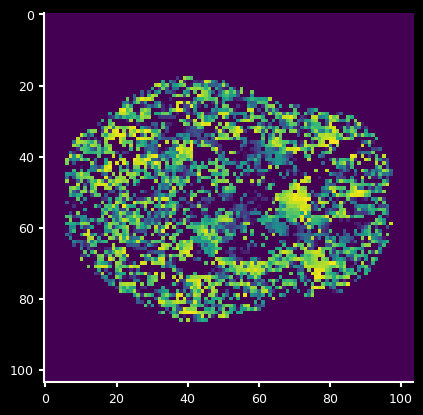

In [408]:
plt.imshow(full_data_s1_dyads[...,28:29,0], vmin=0, vmax=1.)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

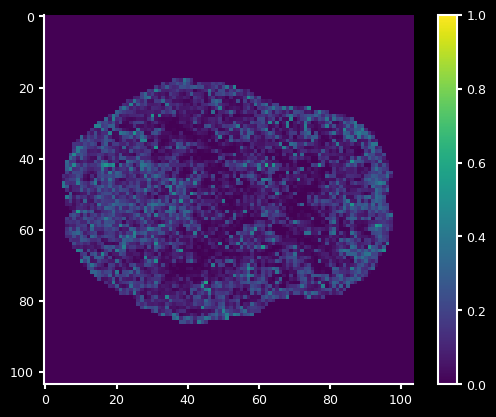

In [410]:
plt.imshow(full_data_s1_dispersion[...,28:29,0], vmin=0, vmax=1.)
plt.colorbar()


In [250]:
full_data_s1_directions = np.zeros(full_data_flat.shape[:-1] + (50, 3))
full_data_s1_directions[brain_mask_flat.astype(np.bool),:,:] = directions_s1_in_brain
full_data_s1_directions = full_data_s1_directions.reshape(data_norm.shape[:-1] + (50, 3))

full_data_s2_directions = np.zeros(full_data_flat.shape[:-1] + (50, 3))
full_data_s2_directions[brain_mask_flat.astype(np.bool),:,:] = directions_s2_in_brain
full_data_s2_directions = full_data_s2_directions.reshape(data_norm.shape[:-1] + (50, 3))

full_data_s3_directions = np.zeros(full_data_flat.shape[:-1] + (50, 3))
full_data_s3_directions[brain_mask_flat.astype(np.bool),:,:] = directions_s3_in_brain
full_data_s3_directions = full_data_s3_directions.reshape(data_norm.shape[:-1] + (50, 3))


In [413]:
full_data_dyads1_unordered = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_dyads1_unordered[brain_mask_flat.astype(np.bool),:] = dyads1_in_brain_unordered
full_data_dyads1_unordered = full_data_dyads1_unordered.reshape(data_norm.shape[:-1] + (3,))

full_data_dyads2_unordered = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_dyads2_unordered[brain_mask_flat.astype(np.bool),:] = dyads2_in_brain_unordered
full_data_dyads2_unordered = full_data_dyads2_unordered.reshape(data_norm.shape[:-1] + (3,))

full_data_dyads3_unordered = np.zeros(full_data_flat.shape[:-1] + (3,))
full_data_dyads3_unordered[brain_mask_flat.astype(np.bool),:] = dyads3_in_brain_unordered
full_data_dyads3_unordered = full_data_dyads3_unordered.reshape(data_norm.shape[:-1] + (3,))


In [418]:
full_data_dyads1_disp_unordered = np.zeros(full_data_flat.shape[:-1])
full_data_dyads1_disp_unordered[brain_mask_flat.astype(np.bool)] = dyads1_disp_unordered
full_data_dyads1_disp_unordered = full_data_dyads1_disp_unordered.reshape(data_norm.shape[:-1])[...,None]

full_data_dyads2_disp_unordered = np.zeros(full_data_flat.shape[:-1])
full_data_dyads2_disp_unordered[brain_mask_flat.astype(np.bool)] = dyads2_disp_unordered
full_data_dyads2_disp_unordered = full_data_dyads2_disp_unordered.reshape(data_norm.shape[:-1])[...,None]

full_data_dyads3_disp_unordered = np.zeros(full_data_flat.shape[:-1])
full_data_dyads3_disp_unordered[brain_mask_flat.astype(np.bool)] = dyads3_disp_unordered
full_data_dyads3_disp_unordered = full_data_dyads3_disp_unordered.reshape(data_norm.shape[:-1])[...,None]


In [415]:
full_data_dyads1_disp_unordered.shape

(104, 104, 72, 1)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

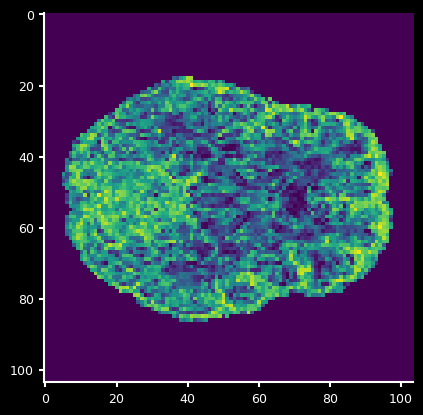

In [422]:
plt.imshow(full_data_dyads1_disp_unordered[...,28:29,0])

In [421]:
# Export results

from dmri.utils.dmriutils import export_nifti
import nibabel as nib
org_data = nib.load("data/data.nii.gz")
new_path = "better_training_data"

export_nifti(full_data_f0_mean, org_data, "", f"{new_path}/f0_fraction_mean.nii.gz")
export_nifti(full_data_f1_mean, org_data, "", f"{new_path}/f1_fraction_mean.nii.gz")
export_nifti(full_data_f2_mean, org_data, "", f"{new_path}/f2_fraction_mean.nii.gz")
export_nifti(full_data_f3_mean, org_data, "", f"{new_path}/f3_fraction_mean.nii.gz")

export_nifti(full_data_f0_std, org_data, "", f"{new_path}/f0_fraction_std.nii.gz")
export_nifti(full_data_f1_std, org_data, "", f"{new_path}/f1_fraction_std.nii.gz")
export_nifti(full_data_f2_std, org_data, "", f"{new_path}/f2_fraction_std.nii.gz")
export_nifti(full_data_f3_std, org_data, "", f"{new_path}/f3_fraction_std.nii.gz")

export_nifti(full_data_diff, org_data, "", f"{new_path}/diffusivity.nii.gz")
export_nifti(full_data_diff_std, org_data, "", f"{new_path}/diffusivity_std.nii.gz")

export_nifti(full_data_s1_dyads, org_data, "", f"{new_path}/s1_dyads_mean.nii.gz")
export_nifti(full_data_s2_dyads, org_data, "", f"{new_path}/s2_dyads_mean.nii.gz")
export_nifti(full_data_s3_dyads, org_data, "", f"{new_path}/s3_dyads_mean.nii.gz")

export_nifti(full_data_s1_dispersion, org_data, "", f"{new_path}/s1_dispersion.nii.gz")
export_nifti(full_data_s2_dispersion, org_data, "", f"{new_path}/s2_dispersion.nii.gz")
export_nifti(full_data_s3_dispersion, org_data, "", f"{new_path}/s3_dispersion.nii.gz")

export_nifti(full_data_pred_error, org_data, "", f"{new_path}/pred_error.nii.gz")
# Save raw_directions

export_nifti(full_data_s1_dyads, org_data, "", f"{new_path}/s1_dyads_mean.nii.gz")

export_nifti(full_data_s1_directions, org_data, "", f"{new_path}/s1_directions_samples_unordered.nii.gz")
export_nifti(full_data_s2_directions, org_data, "", f"{new_path}/s2_directions_samples_unordered.nii.gz")
export_nifti(full_data_s3_directions, org_data, "", f"{new_path}/s3_directions_samples_unordered.nii.gz")

export_nifti(full_data_dyads1_unordered, org_data, "", f"{new_path}/dyads1_unordered.nii.gz")
export_nifti(full_data_dyads2_unordered, org_data, "", f"{new_path}/dyads2_unordered.nii.gz")
export_nifti(full_data_dyads3_unordered, org_data, "", f"{new_path}/dyads3_unordered.nii.gz")

export_nifti(full_data_dyads1_disp_unordered, org_data, "", f"{new_path}/dyads1_disp_unordered.nii.gz")
export_nifti(full_data_dyads2_disp_unordered, org_data, "", f"{new_path}/dyads2_disp_unordered.nii.gz")
export_nifti(full_data_dyads3_disp_unordered, org_data, "", f"{new_path}/dyads3_disp_unordered.nii.gz")
